In [5]:
# %pip install librosa

MOBILE NET

In [6]:
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='librosa')

import numpy as np
import seaborn as sns
import librosa
import shutil
from io import BytesIO
from PIL import Image, ImageOps, ImageFile
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.optimizers import Adam

# Handle truncated image warnings in PIL
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Suppress TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 


In [7]:
data_path = r"C:\Final SEM Project (PG)\ArASL_Database_54K_Final\ArASL_Database_54K_Final"
data = []  
labels = []  
categories = os.listdir(data_path) # List of categories in this dataset

max_images_per_class = 400 

for category in categories:
    category_path = os.path.join(data_path, category) # Full path to the category directory
    images_loaded = 0 
    # Loop over each image in the category
    for img_name in os.listdir(category_path):
        if images_loaded >= max_images_per_class:
            break  # Stop loading more images if the limit is reached
        
        img_path = os.path.join(category_path, img_name) # Full path to the image file
        img = load_img(img_path, target_size=(224, 224))  # Load and resize the image
        img_array = img_to_array(img) # Convert image to a NumPy array
        img_array /= 255.0  # Normalize pixel values to [0,1]
        data.append(img_array)  # Add image array to the data list
        # Add category (label) to the labels list
        labels.append(category)
        
        images_loaded += 1  # Increment the counter

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(data, categorical_labels, test_size=0.2, random_state=42)
X_test,X_val,y_test,y_val=train_test_split(X_test,y_test,test_size=0.5, random_state=42)
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)
print(f'X_train shape is {X_train.shape}')
print(f'X_val shape is {X_val.shape}')
print(f'X_test shape is {X_test.shape}')
print(f'y_train shape is {y_train.shape}')
print(f'y_val shape is {y_val.shape}')
print(f'y_test shape is {y_test.shape}')

X_train shape is (10240, 224, 224, 3)
X_val shape is (1280, 224, 224, 3)
X_test shape is (1280, 224, 224, 3)
y_train shape is (10240, 32)
y_val shape is (1280, 32)
y_test shape is (1280, 32)


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers on top of the MobileNet base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
num_classes = 32  # Replace with your number of classes
predictions = Dense(num_classes, activation='softmax')(x)

# Define the complete model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                      

In [10]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

input_shape = (224, 224, 1)
num_classes = 32

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [11]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
320/320 [==============================] - 300s 918ms/step - loss: 0.9017 - accuracy: 0.7474 - val_loss: 0.1573 - val_accuracy: 0.9531
Epoch 2/100
320/320 [==============================] - 514s 2s/step - loss: 0.2141 - accuracy: 0.9400 - val_loss: 0.0993 - val_accuracy: 0.9672
Epoch 3/100
320/320 [==============================] - 264s 824ms/step - loss: 0.1409 - accuracy: 0.9605 - val_loss: 0.0998 - val_accuracy: 0.9648
Epoch 4/100
320/320 [==============================] - 285s 893ms/step - loss: 0.1118 - accuracy: 0.9662 - val_loss: 0.0934 - val_accuracy: 0.9695
Epoch 5/100
320/320 [==============================] - 262s 820ms/step - loss: 0.0899 - accuracy: 0.9747 - val_loss: 0.0994 - val_accuracy: 0.9719
Epoch 6/100
320/320 [==============================] - 295s 924ms/step - loss: 0.0761 - accuracy: 0.9762 - val_loss: 0.0763 - val_accuracy: 0.9750
Epoch 7/100
320/320 [==============================] - 277s 865ms/step - loss: 0.0719 - accuracy: 0.9782 - val_loss: 0.08

In [12]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

40/40 [==============================] - 29s 712ms/step - loss: 0.0453 - accuracy: 0.9852
Test Accuracy: 98.52%


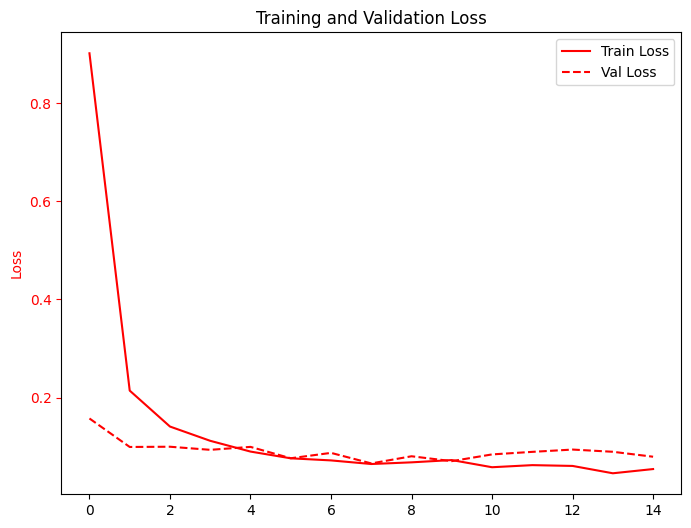

In [13]:
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.plot(history.history['loss'], 'r-', label='Train Loss')
ax2.plot(history.history['val_loss'], 'r--', label='Val Loss')
ax2.set_ylabel('Loss', color='r')
ax2.tick_params('y', colors='r')
ax2.legend(loc='upper right')

plt.title('Training and Validation Loss')
plt.show()

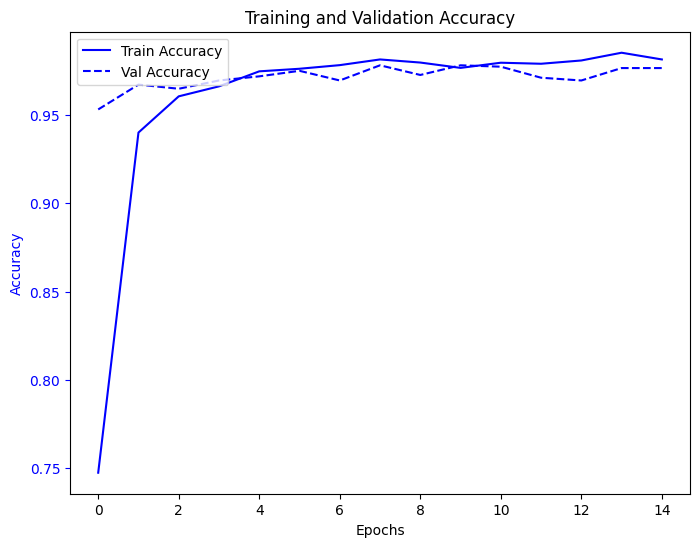

In [14]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot accuracy
ax1.plot(history.history['accuracy'], 'b-', label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], 'b--', label='Val Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params('y', colors='b')
plt.title('Training and Validation Accuracy')
ax1.legend(loc='upper left')

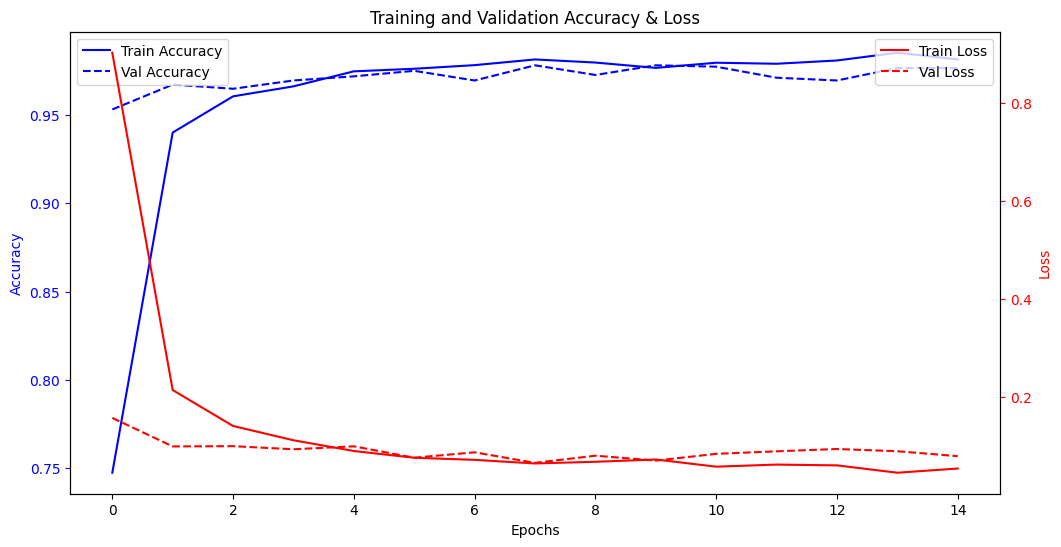

In [15]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot accuracy
ax1.plot(history.history['accuracy'], 'b-', label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], 'b--', label='Val Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params('y', colors='b')
ax1.legend(loc='upper left')

# Create a second y-axis for loss
ax2 = ax1.twinx()
ax2.plot(history.history['loss'], 'r-', label='Train Loss')
ax2.plot(history.history['val_loss'], 'r--', label='Val Loss')
ax2.set_ylabel('Loss', color='r')
ax2.tick_params('y', colors='r')
ax2.legend(loc='upper right')

plt.title('Training and Validation Accuracy & Loss')
plt.show()


40/40 [==============================] - 28s 670ms/step


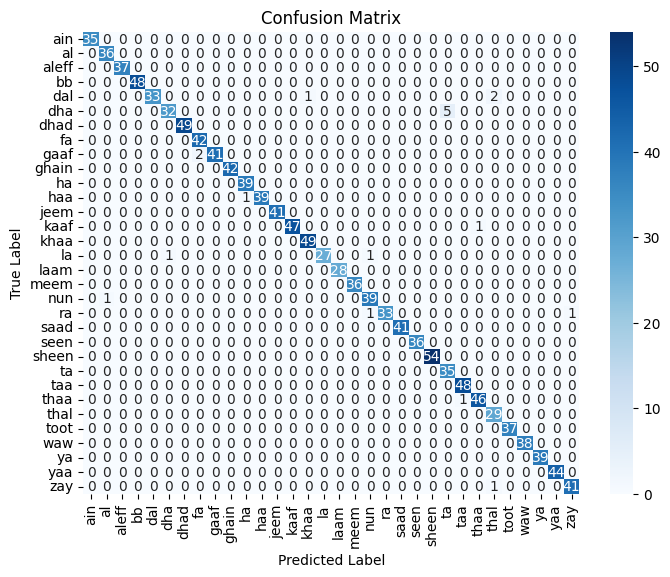

In [16]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



In [17]:
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=categories))


Classification Report:
              precision    recall  f1-score   support

         ain       1.00      1.00      1.00        35
          al       0.97      1.00      0.99        36
       aleff       1.00      1.00      1.00        37
          bb       1.00      1.00      1.00        48
         dal       1.00      0.92      0.96        36
         dha       0.97      0.86      0.91        37
        dhad       1.00      1.00      1.00        49
          fa       0.95      1.00      0.98        42
        gaaf       1.00      0.95      0.98        43
       ghain       1.00      1.00      1.00        42
          ha       0.97      1.00      0.99        39
         haa       1.00      0.97      0.99        40
        jeem       1.00      1.00      1.00        41
        kaaf       1.00      0.98      0.99        48
        khaa       0.98      1.00      0.99        49
          la       1.00      0.93      0.96        29
        laam       1.00      1.00      1.00        28
   

40/40 [==============================] - 27s 664ms/step


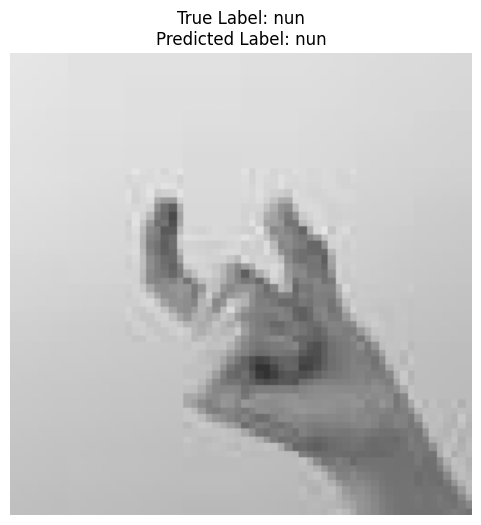

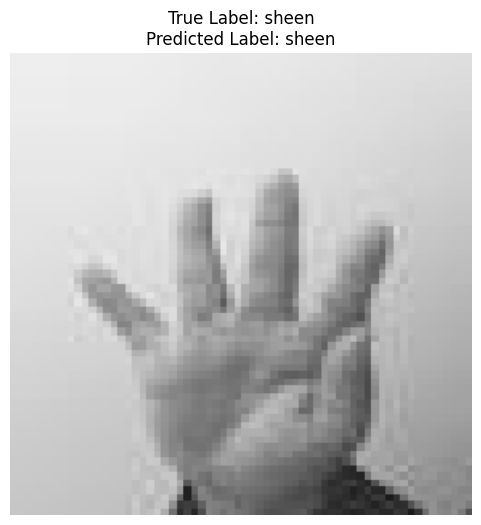

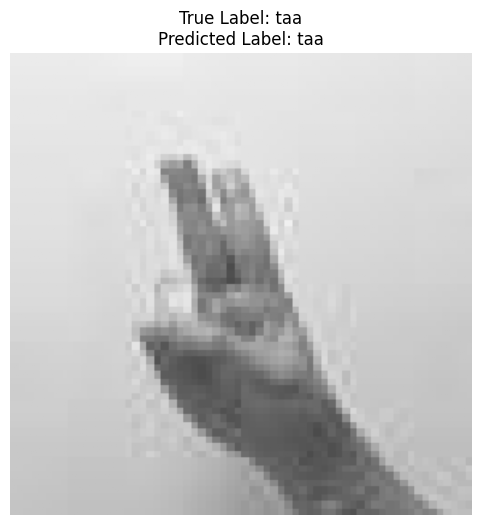

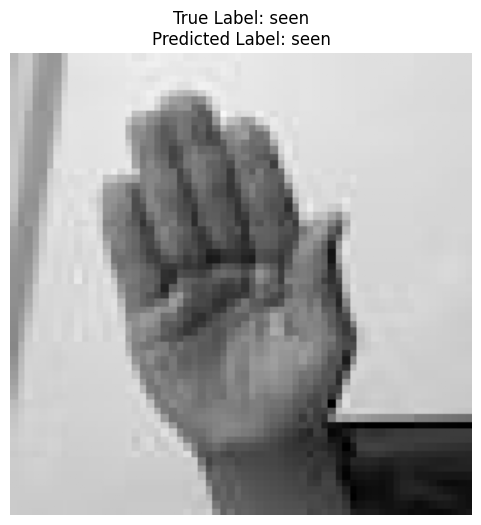

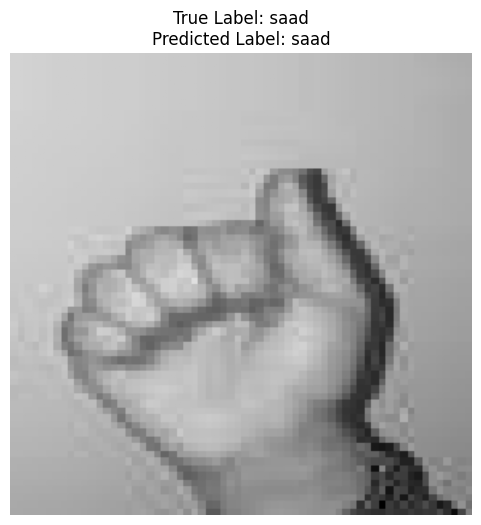

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Function to plot image with title
def plot_image(img_array, true_label, pred_label):
    plt.figure(figsize=(6, 6))
    plt.imshow(img_array)
    plt.title(f"True Label: {true_label}\nPredicted Label: {pred_label}")
    plt.axis('off')
    plt.show()

# Plot a few test images with actual and predicted class names
num_images_to_plot = 5 
for i in range(num_images_to_plot):
    # Get the image and its true label
    img = X_test[i]
    true_label = label_encoder.inverse_transform([y_true_classes[i]])[0]
    # Get the predicted label
    pred_label = label_encoder.inverse_transform([y_pred_classes[i]])[0]
    
    # Plot the image with title showing true and predicted labels
    plot_image(img, true_label, pred_label)


In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Define class labels for Arabic Sign Language
class_labels = [
    'ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 
    'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 
    'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 
    'ya', 'yaa', 'zay'
]

# Load and preprocess the image
def preprocess_image(img_path):
    img = image.load_img(img_path, color_mode='grayscale', target_size=(224, 224))  # Load image as grayscale
    img_array = image.img_to_array(img)  # Convert image to numpy array
    img_array = np.repeat(img_array, 3, axis=-1)  # Convert grayscale to RGB by duplicating channels
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize to [0, 1] range
    return img_array

# Predict on a new image
def predict_image(img_path):
    img_array = preprocess_image(img_path)
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])  # Get the index of the highest probability
    confidence = np.max(predictions[0])  # Get the highest probability
    return class_labels[predicted_class], confidence

# Example usage
img_path = r"C:\Final SEM Project (PG)\ArASL_Database_54K_Final\ArASL_Database_54K_Final\ghain\GHAIN (27).JPG"
predicted_label, confidence = predict_image(img_path)
print(f"Predicted Label: {predicted_label}")
print(f"Confidence: {confidence:.4f}")

1/1 [==============================] - 1s 562ms/step
Predicted Label: yaa
Confidence: 0.6523


In [28]:
# Save the trained model to an H5 file
model_save_path = r'C:\Final SEM Project (PG)\24MCA21\Code\arabic_sign_language_model.h5'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to C:\Final SEM Project (PG)\24MCA21\Code\arabic_sign_language_model.h5


In [29]:
# Save the trained model to an H5 file
model_save_path = r'C:\Final SEM Project (PG)\24MCA21\Code\arabic_sign_language_model.keras'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to C:\Final SEM Project (PG)\24MCA21\Code\arabic_sign_language_model.keras


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define a training ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
print(train_generator.class_indices)

Found 54049 images belonging to 32 classes.
{'ain': 0, 'al': 1, 'aleff': 2, 'bb': 3, 'dal': 4, 'dha': 5, 'dhad': 6, 'fa': 7, 'gaaf': 8, 'ghain': 9, 'ha': 10, 'haa': 11, 'jeem': 12, 'kaaf': 13, 'khaa': 14, 'la': 15, 'laam': 16, 'meem': 17, 'nun': 18, 'ra': 19, 'saad': 20, 'seen': 21, 'sheen': 22, 'ta': 23, 'taa': 24, 'thaa': 25, 'thal': 26, 'toot': 27, 'waw': 28, 'ya': 29, 'yaa': 30, 'zay': 31}


In [31]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load model
model = load_model(r"C:\Final SEM Project (PG)\arabic_sign_language_model.h5")

print("Model Loaded Successfully!")

# Load test image
img = image.load_img(r"C:\Final SEM Project (PG)\ArASL_Database_54K_Final\wvl.jpg", target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

print("Predicted Class Index:", predicted_index)

Model Loaded Successfully!
1/1 [==============================] - 1s 899ms/step
Predicted Class Index: 22


In [32]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load model
model = load_model(r"C:\Final SEM Project (PG)\arabic_sign_language_model.keras")

print("Model Loaded Successfully!")

# Load test image
img = image.load_img(r"C:\Final SEM Project (PG)\ArASL_Database_54K_Final\Featured-Image-22.jpg", target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

print("Predicted Class Index:", predicted_index)

Model Loaded Successfully!
1/1 [==============================] - 1s 851ms/step
Predicted Class Index: 20
